In [ ]:
# STEP 1: INSTALL & IMPORT NECESSARY TOOLS
# In Google Colab, you need to install yfinance first. 
# Un-comment the line below if running for the first time:
# !pip install yfinance

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# STEP 2: DOWNLOAD REAL STOCK DATA
print("📥 Fetching historical stock data...")
ticker = "AAPL"  # Feel free to change to 'TSLA', 'MSFT', or 'BTC-USD'
data = yf.download(ticker, start="2023-01-01", end="2026-01-01")

# Calculate daily percentage returns
# We drop the first row because it will be "NaN" (no previous day to compare to)
daily_returns = data['Close'].pct_change().dropna()


In [2]:
daily_returns

Ticker,AAPL
Date,
2023-01-04,0.010314
2023-01-05,-0.010605
2023-01-06,0.036794
2023-01-09,0.004089
2023-01-10,0.004456
...,...
2025-12-24,0.005324
2025-12-26,-0.001497
2025-12-29,0.001317


In [ ]:
# STEP 3: CALCULATE KEY STATISTICS (THE "DRIFT")

# We find out how much the stock moves on average and its risk (volatility)
average_daily_return = daily_returns.mean().values[0]
daily_volatility = daily_returns.std().values[0]

# Get the very last known closing price to start our simulation from
last_price = data['Close'].iloc[-1].values[0]

print(f"\n📊 --- {ticker} Statistics Found ---")
print(f"Starting Price: ${last_price:.2f}")
print(f"Average Daily Move: {average_daily_return * 100:.3f}%")
print(f"Daily Volatility (Risk): {daily_volatility * 100:.2f}%")

# ==========================================
# STEP 4: SETUP THE SIMULATION PARAMETERS
# ==========================================
days_to_forecast = 30     # How many days into the future?
number_of_trials = 100    # How many random future paths to generate?

# Create a blank grid/matrix to store our simulated future prices
# Rows = future days, Columns = unique simulation paths
simulated_prices = np.zeros((days_to_forecast, number_of_trials))

# Start every single simulation path at today's actual stock price
simulated_prices[0] = last_price

# ==========================================
# STEP 5: RUN THE MONTE CARLO LOOP
# ==========================================
print(f"\n🎲 Simulating {number_of_trials} possible futures for the next {days_to_forecast} days...")

for day in range(1, days_to_forecast):
    # For each path, pick a completely random number from a normal distribution curve
    # This simulates the random "shocks" or news events in the stock market
    # Normal distribution curve np.random.normal(0, 1) represents everyday market life. 
    # Most random numbers will fall near zero (boring news days). Occasionally, the code 
    # generates a large number (+3 or -3), representing a massive headline or earnings surprise.
    random_shocks = np.random.normal(0, 1, number_of_trials)
    
    # Mathematical Formula: Tomorrow's Price = Today's Price * (1 + Average Move + (Random Shock * Volatility))
    simulated_prices[day] = simulated_prices[day - 1] * (1 + average_daily_return + (random_shocks * daily_volatility))


📥 Fetching historical stock data...


[*********************100%***********************]  1 of 1 completed



📊 --- AAPL Statistics Found ---
Starting Price: $271.36
Average Daily Move: 0.118%
Daily Volatility (Risk): 1.61%

🎲 Simulating 100 possible futures for the next 30 days...


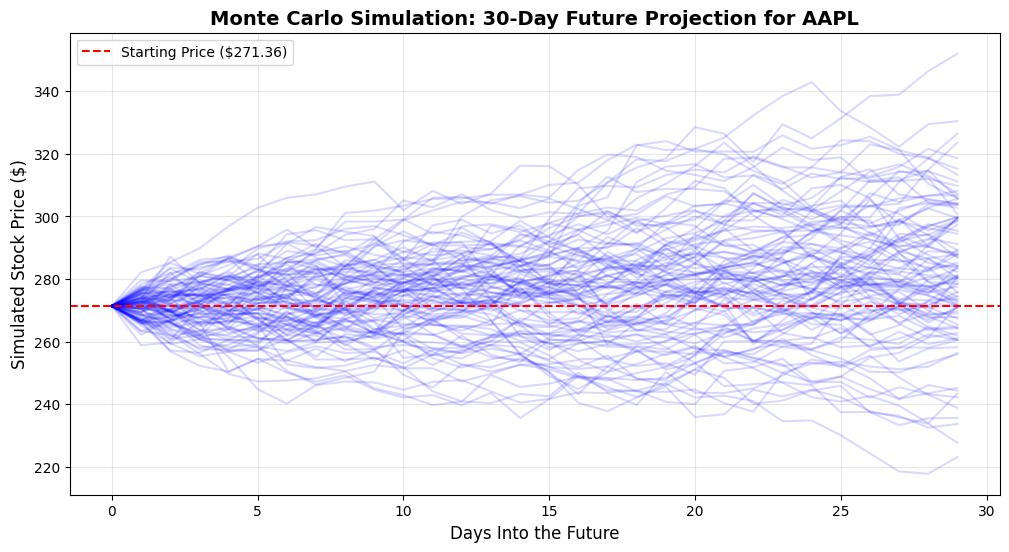

In [1]:
# STEP 6: PLOT THE VISUAL RESULT
# The "Price Funnel" Visual : Notice how the lines are tight on Day 1 but spread widely by Day 30. 
# This is because uncertainty compounds over time. We might have a good guess about 
# tomorrow's stock price, but a month from now, the possibilities expand vastly.


plt.figure(figsize=(12, 6))
plt.plot(simulated_prices, color='blue', alpha=0.15)  # Fade lines to create a beautiful cloud effect
plt.title(f"Monte Carlo Simulation: 30-Day Future Projection for {ticker}", fontsize=14, fontweight='bold')
plt.xlabel("Days Into the Future", fontsize=12)
plt.ylabel("Simulated Stock Price ($)", fontsize=12)
plt.axhline(last_price, color='red', linestyle='--', label=f"Starting Price (${last_price:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



🧮 --- SIMULATION RESULTS & PROBABILITIES ---
Total Paths Simulated: 100
Paths ending HIGHER than start: 70
📈 Chance the stock goes UP: 70.0%
📉 Chance the stock goes DOWN: 30.0%


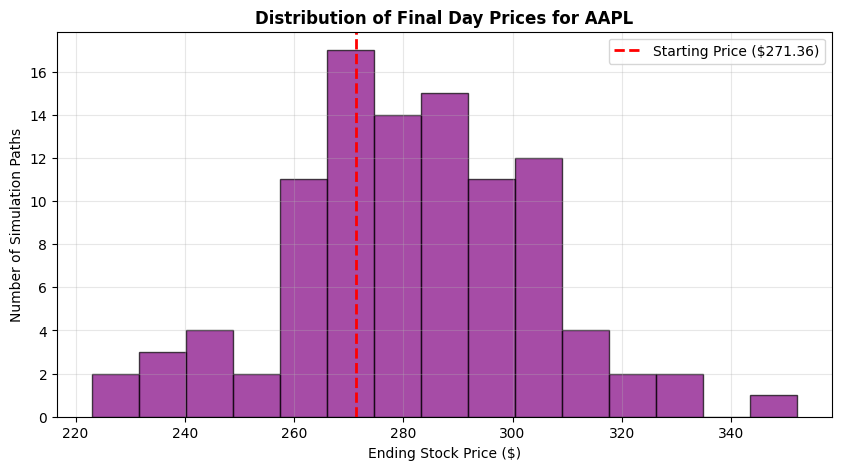

In [3]:
 # calculates the exact percentage chance of the stock going up or down based on these 100 trials

# CALCULATE THE PROBABILITIES
# ==========================================
print("\n🧮 --- SIMULATION RESULTS & PROBABILITIES ---")

# Get all the final prices at the very last day of our simulation (Day 30)
final_prices = simulated_prices[-1, :]

# Count how many paths ended HIGHER than our starting price
successful_paths = np.sum(final_prices > last_price)

# Calculate percentages
chance_up = (successful_paths / number_of_trials) * 100
chance_down = 100 - chance_up

print(f"Total Paths Simulated: {number_of_trials}")
print(f"Paths ending HIGHER than start: {successful_paths}")
print(f"📈 Chance the stock goes UP: {chance_up:.1f}%")
print(f"📉 Chance the stock goes DOWN: {chance_down:.1f}%")

# ==========================================
# STEP 8: BONUS VISUAL (HISTOGRAM OF VISUAL OUTCOMES)
# ==========================================
plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=15, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(last_price, color='red', linestyle='--', linewidth=2, label=f"Starting Price (${last_price:.2f})")
plt.title(f"Distribution of Final Day Prices for {ticker}", fontsize=12, fontweight='bold')
plt.xlabel("Ending Stock Price ($)")
plt.ylabel("Number of Simulation Paths")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
